# Equity Index Analysis

This notebook analyzes the relationship between a universe of individual U.S. equities and several MSCI USA factor indices. We compute monthly returns for each stock and index, examine the correlation between each stock and each index, and visualize the distribution of these correlations. We also identify the most correlated stocks for each factor index, compare exposures across indices, and study market regimes based on the performance of the broad MSCI US Equity Index. 

The indices examined are:
- **MSCI US Equity** (broad market benchmark)
- **MSCI Value** (captures value characteristics among large and mid-cap stocks)
- **MSCI Momentum** (measures momentum factor exposure)
- **MSCI Low Volatility** (targets lower volatility stocks)
- **MSCI High Dividend Yield** (focuses on higher dividend-paying stocks)
- **MSCI Low Size** (small-cap tilt)

The dataset contains daily price series for about 300 U.S. stocks and these indices. We convert prices to monthly returns and perform the analyses below.


In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('merged_equity_macro.csv')
# Parse dates and set index
if 'Dates' in df.columns:
    df['Dates'] = pd.to_datetime(df['Dates'], errors='coerce')
    df = df.dropna(subset=['Dates'])
    df = df.sort_values('Dates')
    df.set_index('Dates', inplace=True)
# Define index columns
index_cols = ['MSCI US Equity', 'MSCI Low Size', 'MSCI Value', 'MSCI Momentum', 'MSCI Low Vol', 'MSCI High Div Yield']
index_cols = [c for c in index_cols if c in df.columns]
stock_cols = [col for col in df.columns if col not in index_cols]
# Compute returns
returns = df[stock_cols + index_cols].pct_change(fill_method=None)
stock_returns = returns[stock_cols]
index_returns = returns[index_cols]
print(f"Number of stocks: {len(stock_cols)}")



Number of stocks: 240


In [10]:
print(stock_returns)

            KATE US Equity  KBH US Equity  KDP US Equity  KEY US Equity  \
Dates                                                                     
1999-01-29             NaN            NaN            NaN            NaN   
1999-02-26       -0.117839      -0.201777            NaN       0.011765   
1999-03-31       -0.031543       0.002782            NaN      -0.060078   
1999-04-30        0.013413       0.077562            NaN       0.020619   
1999-05-31        0.088844      -0.007716            NaN       0.123232   
...                    ...            ...            ...            ...   
2019-08-30        0.000000       0.069281      -0.030561      -0.096353   
2019-09-30        0.000000       0.210395       0.001466       0.074699   
2019-10-31        0.000000       0.049706       0.030747       0.007287   
2019-11-29        0.000000      -0.031101       0.098722       0.079021   
2019-12-31        0.000000      -0.008965      -0.064318       0.043837   

            KEYS US Equi

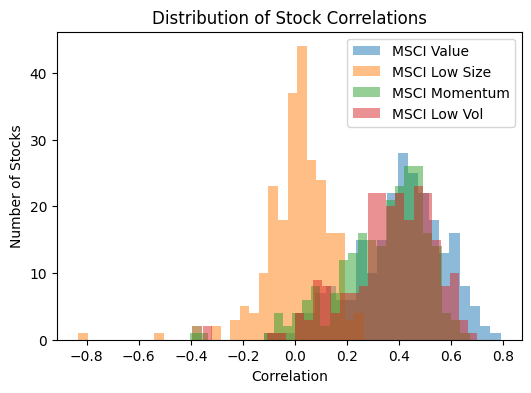

(KATE US Equity    0.418110
 KBH US Equity     0.468423
 KDP US Equity     0.243605
 KEY US Equity     0.472779
 KEYS US Equity    0.476253
 dtype: float64,
 KATE US Equity    0.160155
 KBH US Equity    -0.003027
 KDP US Equity     0.089829
 KEY US Equity     0.069006
 KEYS US Equity   -0.292061
 dtype: float64)

In [17]:
# correlation series for each index (stock-by-stock)
corr_value = stock_returns.corrwith(index_returns['MSCI Value']).dropna()
corr_low_size = stock_returns.corrwith(index_returns['MSCI Low Size']).dropna()
corr_momentum = stock_returns.corrwith(index_returns['MSCI Momentum']).dropna()
corr_low_vol = stock_returns.corrwith(index_returns['MSCI Low Vol']).dropna()

plt.figure(figsize=(6,4))
plt.hist(corr_value, bins=30, alpha=0.5, label='MSCI Value')
plt.hist(corr_low_size, bins=30, alpha=0.5, label='MSCI Low Size')
plt.hist(corr_momentum, bins=30, alpha=0.5, label='MSCI Momentum')
plt.hist(corr_low_vol, bins=30, alpha=0.5, label='MSCI Low Vol')
plt.title('Distribution of Stock Correlations')
plt.xlabel('Correlation')
plt.ylabel('Number of Stocks')
plt.legend()
plt.show()

corr_value.head(), corr_low_size.head()

In [18]:
summary = pd.DataFrame({
    'Value': corr_value,
    'Low Size': corr_low_size,
    'Momentum': corr_momentum,
    'Low Vol': corr_low_vol
}).describe()

summary

,Value,Low Size,Momentum,Low Vol
count,240.000000,240.000000,240.000000,240.000000
mean,0.395924,0.010878,0.334893,0.367743
std,0.183200,0.124104,0.171608,0.167172
min,-0.397585,-0.833342,-0.404650,-0.352419
25%,0.296460,-0.047967,0.236635,0.299058
50%,0.416205,0.021041,0.376294,0.389267
75%,0.517589,0.084541,0.458054,0.486222
max,0.790104,0.263614,0.670173,0.700722


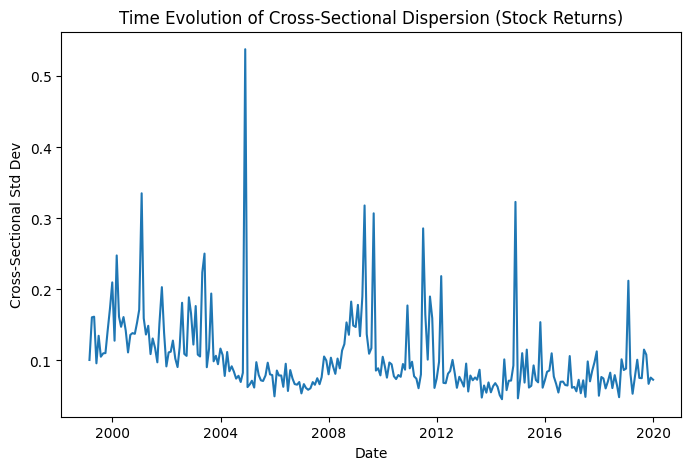

count    251.000000
mean       0.104317
std        0.056770
min        0.045477
25%        0.070931
50%        0.086603
75%        0.114695
max        0.538222
dtype: float64

In [19]:
# Cross-sectional dispersion of stock returns
xs_disp = stock_returns.std(axis=1)

plt.figure(figsize=(8,5))
plt.plot(xs_disp)
plt.title("Time Evolution of Cross-Sectional Dispersion (Stock Returns)")
plt.ylabel("Cross-Sectional Std Dev")
plt.xlabel("Date")
plt.show()

xs_disp.describe()

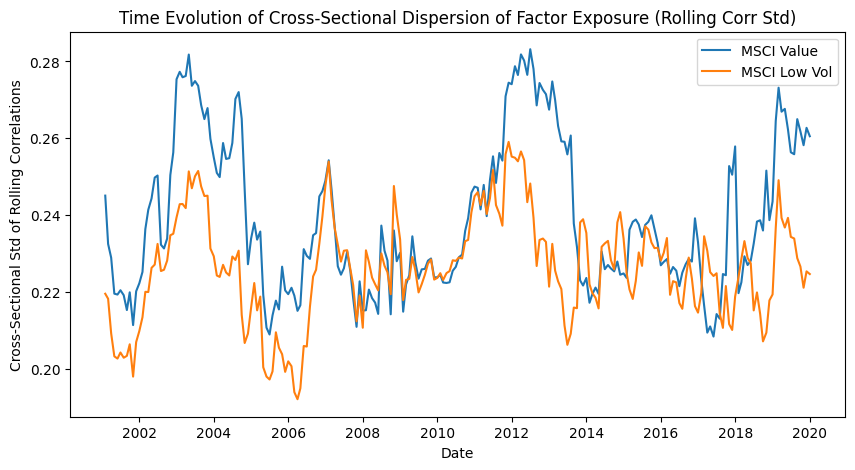

,MSCI Value,MSCI Low Vol
count,228.000000,228.000000
mean,0.239008,0.226189
std,0.019548,0.013654
min,0.208424,0.192127
25%,0.224251,0.218747
50%,0.233302,0.225810
75%,0.254684,0.233929
max,0.283179,0.259074


In [24]:
window = 24  # months

dispersion = {}

index_cols = ['MSCI Value', 'MSCI Low Vol']

for idx in index_cols:
    # rolling correlation for each stock vs this index
    roll_corr = stock_returns.rolling(window).corr(index_returns[idx])  # DataFrame, same shape as stocks
    
    # cross-sectional dispersion at each date (std across stocks)
    dispersion[idx] = roll_corr.std(axis=1, skipna=True)

dispersion_df = pd.DataFrame(dispersion)

plt.figure(figsize=(10,5))
for col in dispersion_df.columns:
    plt.plot(dispersion_df.index, dispersion_df[col], label=col)

plt.title("Time Evolution of Cross-Sectional Dispersion of Factor Exposure (Rolling Corr Std)")
plt.ylabel("Cross-Sectional Std of Rolling Correlations")
plt.xlabel("Date")
plt.legend()
plt.show()

dispersion_df.describe()

In [25]:
factor_corr = index_returns[['MSCI Value','MSCI Low Vol',
                             'MSCI Momentum','MSCI Low Size']].corr()

factor_corr

,MSCI Value,MSCI Low Vol,MSCI Momentum,MSCI Low Size
MSCI Value,1.000000,0.909221,0.746248,0.067761
MSCI Low Vol,0.909221,1.000000,0.797402,0.066680
MSCI Momentum,0.746248,0.797402,1.000000,0.042552
MSCI Low Size,0.067761,0.066680,0.042552,1.000000


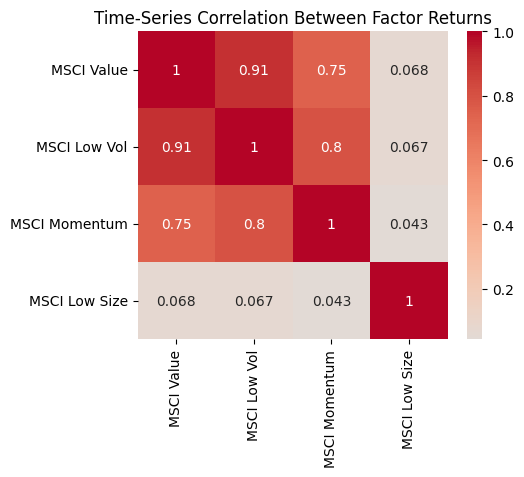

In [26]:
plt.figure(figsize=(5,4))
sns.heatmap(factor_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Time-Series Correlation Between Factor Returns")
plt.show()

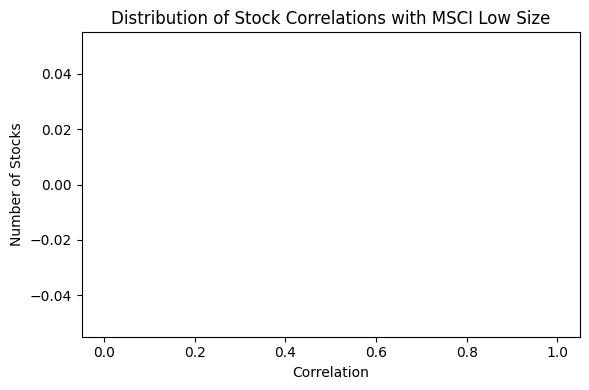

In [3]:
# Correlation distribution for MSCI Low Size
corr_series = stock_returns.corrwith(index_returns['MSCI Low Size']).dropna()
plt.figure(figsize=(6,4))
plt.hist(corr_series, bins=30, color='steelblue', alpha=0.7)
plt.title('Distribution of Stock Correlations with MSCI Low Size')
plt.xlabel('Correlation')
plt.ylabel('Number of Stocks')
plt.show()
corr_series.head()


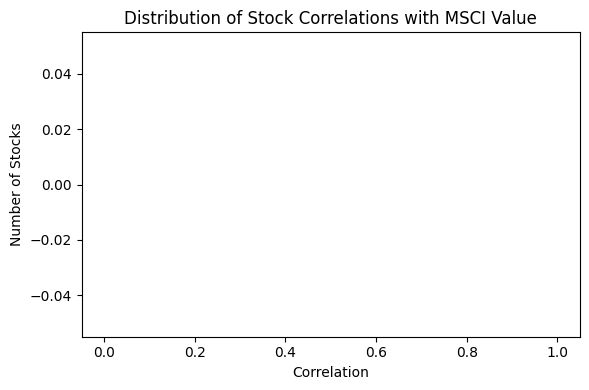

In [4]:
# Correlation distribution for MSCI Value
corr_series = stock_returns.corrwith(index_returns['MSCI Value']).dropna()
plt.figure(figsize=(6,4))
plt.hist(corr_series, bins=30, color='steelblue', alpha=0.7)
plt.title('Distribution of Stock Correlations with MSCI Value')
plt.xlabel('Correlation')
plt.ylabel('Number of Stocks')
plt.show()
corr_series.head()


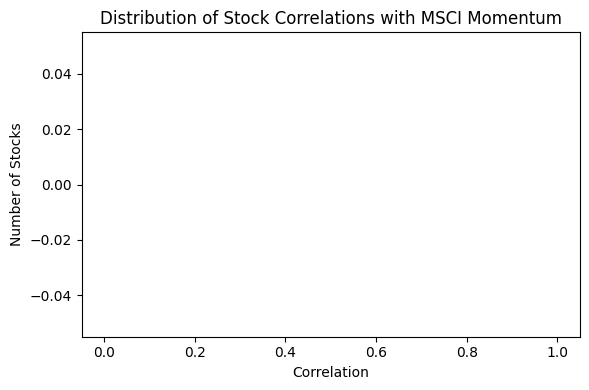

In [5]:
# Correlation distribution for MSCI Momentum
corr_series = stock_returns.corrwith(index_returns['MSCI Momentum']).dropna()
plt.figure(figsize=(6,4))
plt.hist(corr_series, bins=30, color='steelblue', alpha=0.7)
plt.title('Distribution of Stock Correlations with MSCI Momentum')
plt.xlabel('Correlation')
plt.ylabel('Number of Stocks')
plt.show()
corr_series.head()


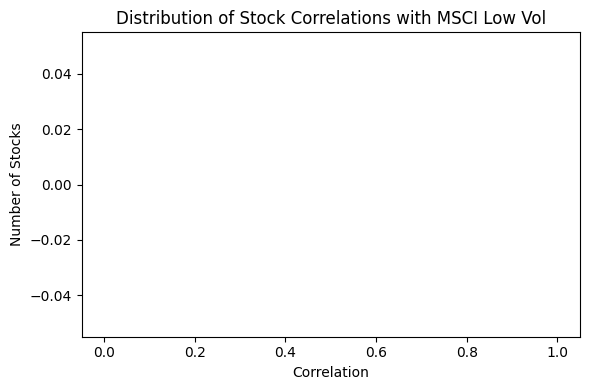

In [6]:
# Correlation distribution for MSCI Low Vol
corr_series = stock_returns.corrwith(index_returns['MSCI Low Vol']).dropna()
plt.figure(figsize=(6,4))
plt.hist(corr_series, bins=30, color='steelblue', alpha=0.7)
plt.title('Distribution of Stock Correlations with MSCI Low Vol')
plt.xlabel('Correlation')
plt.ylabel('Number of Stocks')
plt.show()
corr_series.head()


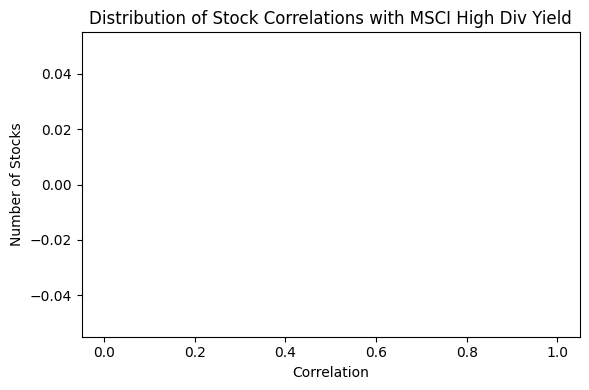

In [7]:
# Correlation distribution for MSCI High Div Yield
corr_series = stock_returns.corrwith(index_returns['MSCI High Div Yield']).dropna()
plt.figure(figsize=(6,4))
plt.hist(corr_series, bins=30, color='steelblue', alpha=0.7)
plt.title('Distribution of Stock Correlations with MSCI High Div Yield')
plt.xlabel('Correlation')
plt.ylabel('Number of Stocks')
plt.show()
corr_series.head()


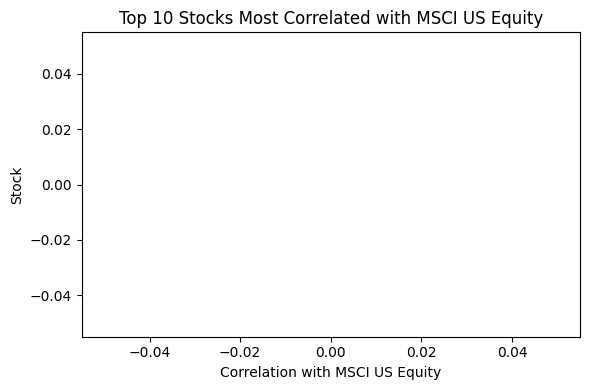

Series([], )

In [8]:
# Top 10 stocks correlated with MSCI US Equity
corr_series = stock_returns.corrwith(index_returns['MSCI US Equity']).dropna()
top10 = corr_series.sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4))
plt.barh(top10.index[::-1], top10.values[::-1], color=plt.cm.viridis(np.linspace(0,1,10)))
plt.title('Top 10 Stocks Most Correlated with MSCI US Equity')
plt.xlabel('Correlation with MSCI US Equity')
plt.ylabel('Stock')
plt.show()
top10


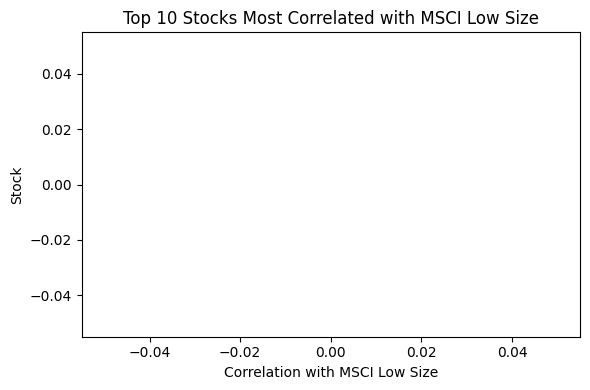

Series([], )

In [9]:
# Top 10 stocks correlated with MSCI Low Size
corr_series = stock_returns.corrwith(index_returns['MSCI Low Size']).dropna()
top10 = corr_series.sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4))
plt.barh(top10.index[::-1], top10.values[::-1], color=plt.cm.viridis(np.linspace(0,1,10)))
plt.title('Top 10 Stocks Most Correlated with MSCI Low Size')
plt.xlabel('Correlation with MSCI Low Size')
plt.ylabel('Stock')
plt.show()
top10


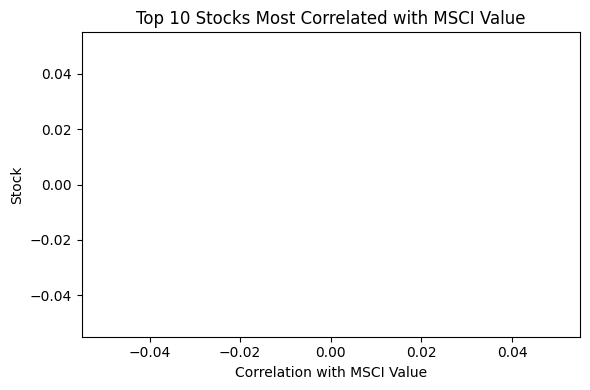

Series([], )

In [10]:
# Top 10 stocks correlated with MSCI Value
corr_series = stock_returns.corrwith(index_returns['MSCI Value']).dropna()
top10 = corr_series.sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4))
plt.barh(top10.index[::-1], top10.values[::-1], color=plt.cm.viridis(np.linspace(0,1,10)))
plt.title('Top 10 Stocks Most Correlated with MSCI Value')
plt.xlabel('Correlation with MSCI Value')
plt.ylabel('Stock')
plt.show()
top10


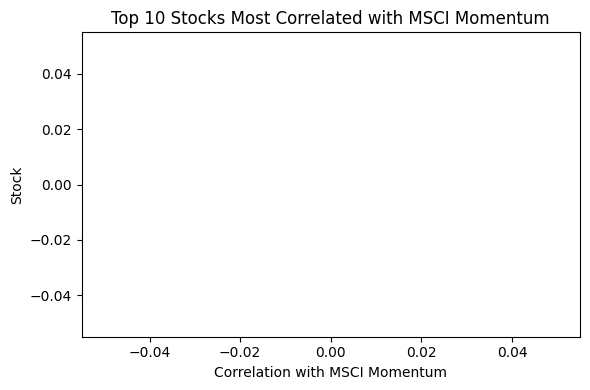

Series([], )

In [11]:
# Top 10 stocks correlated with MSCI Momentum
corr_series = stock_returns.corrwith(index_returns['MSCI Momentum']).dropna()
top10 = corr_series.sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4))
plt.barh(top10.index[::-1], top10.values[::-1], color=plt.cm.viridis(np.linspace(0,1,10)))
plt.title('Top 10 Stocks Most Correlated with MSCI Momentum')
plt.xlabel('Correlation with MSCI Momentum')
plt.ylabel('Stock')
plt.show()
top10


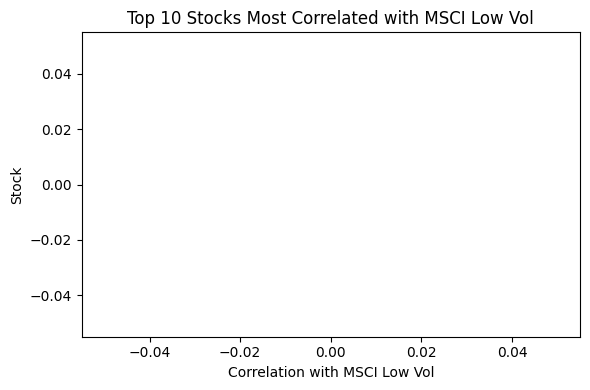

Series([], )

In [12]:
# Top 10 stocks correlated with MSCI Low Vol
corr_series = stock_returns.corrwith(index_returns['MSCI Low Vol']).dropna()
top10 = corr_series.sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4))
plt.barh(top10.index[::-1], top10.values[::-1], color=plt.cm.viridis(np.linspace(0,1,10)))
plt.title('Top 10 Stocks Most Correlated with MSCI Low Vol')
plt.xlabel('Correlation with MSCI Low Vol')
plt.ylabel('Stock')
plt.show()
top10


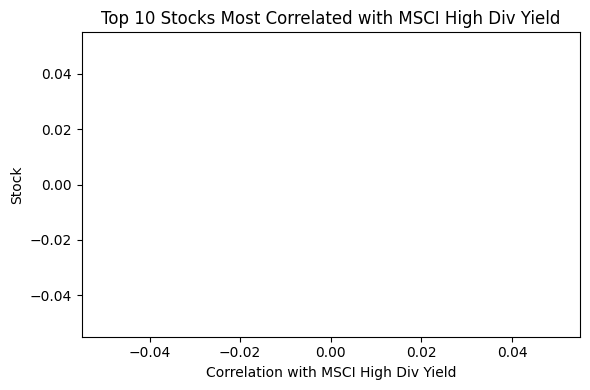

Series([], )

In [13]:
# Top 10 stocks correlated with MSCI High Div Yield
corr_series = stock_returns.corrwith(index_returns['MSCI High Div Yield']).dropna()
top10 = corr_series.sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4))
plt.barh(top10.index[::-1], top10.values[::-1], color=plt.cm.viridis(np.linspace(0,1,10)))
plt.title('Top 10 Stocks Most Correlated with MSCI High Div Yield')
plt.xlabel('Correlation with MSCI High Div Yield')
plt.ylabel('Stock')
plt.show()
top10


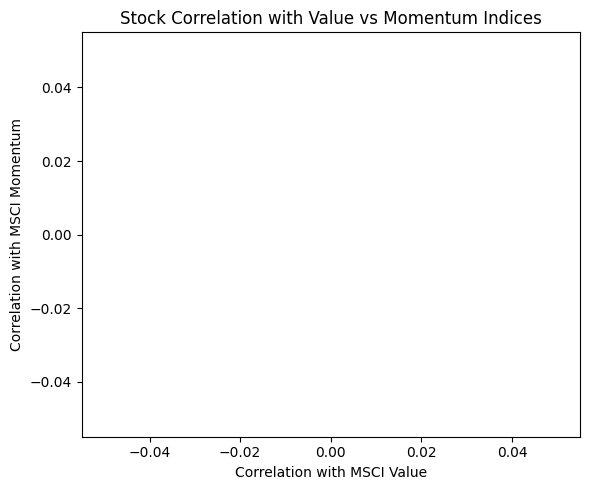

Empty DataFrame
Columns: [Value, Momentum, diff]
Index: []

In [14]:
# Scatter of Value vs Momentum exposures
value_corr = stock_returns.corrwith(index_returns['MSCI Value']).dropna()
momentum_corr = stock_returns.corrwith(index_returns['MSCI Momentum']).dropna()
scatter_df = pd.DataFrame({'Value': value_corr, 'Momentum': momentum_corr})
plt.figure(figsize=(6,5))
plt.scatter(scatter_df['Value'], scatter_df['Momentum'], alpha=0.6, s=20)
plt.title('Stock Correlation with Value vs Momentum Indices')
plt.xlabel('Correlation with MSCI Value')
plt.ylabel('Correlation with MSCI Momentum')
scatter_df['diff'] = (scatter_df['Value'] - scatter_df['Momentum']).abs()
top_diff = scatter_df.sort_values('diff', ascending=False).head(5)
for stock, row in top_diff.iterrows():
    plt.annotate(stock, (row['Value'], row['Momentum']), textcoords='offset points', xytext=(3,3), fontsize=8)
plt.show()
top_diff


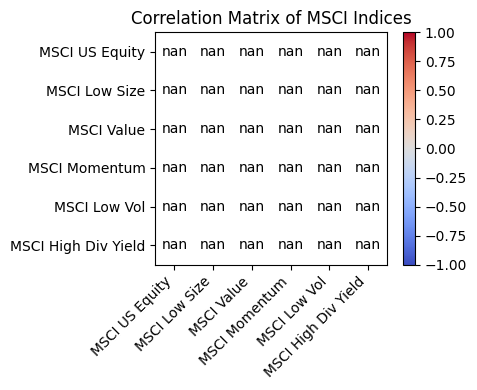

                     MSCI US Equity  MSCI Low Size  MSCI Value  MSCI Momentum  MSCI Low Vol  MSCI High Div Yield
MSCI US Equity                  NaN            NaN         NaN            NaN           NaN                  NaN
MSCI Low Size                   NaN            NaN         NaN            NaN           NaN                  NaN
MSCI Value                      NaN            NaN         NaN            NaN           NaN                  NaN
MSCI Momentum                   NaN            NaN         NaN            NaN           NaN                  NaN
MSCI Low Vol                    NaN            NaN         NaN            NaN           NaN                  NaN
MSCI High Div Yield             NaN            NaN         NaN            NaN           NaN                  NaN

In [15]:
# Heatmap of index correlation matrix
corr_matrix = index_returns.corr()
plt.figure(figsize=(5,4))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix)), corr_matrix.index)
plt.title('Correlation Matrix of MSCI Indices')
plt.colorbar(im)
plt.show()
corr_matrix


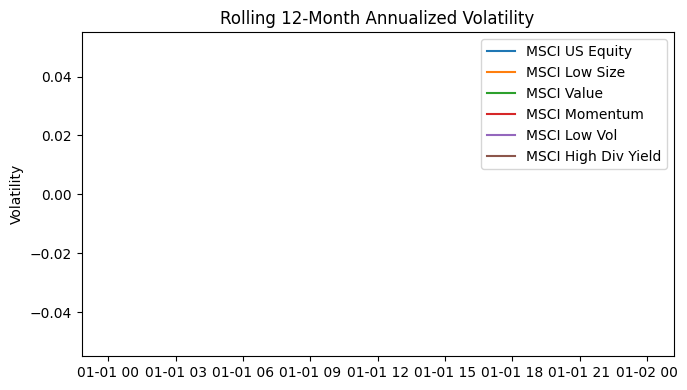

Empty DataFrame
Columns: [MSCI US Equity, MSCI Low Size, MSCI Value, MSCI Momentum, MSCI Low Vol, MSCI High Div Yield]
Index: []

In [16]:
# Rolling 12-month annualized volatility
volatility = index_returns.rolling(window=12).std() * np.sqrt(12)
plt.figure(figsize=(7,4))
for col in index_cols:
    plt.plot(volatility.index, volatility[col], label=col)
plt.title('Rolling 12-Month Annualized Volatility')
plt.ylabel('Volatility')
plt.legend()
plt.show()
volatility.tail()


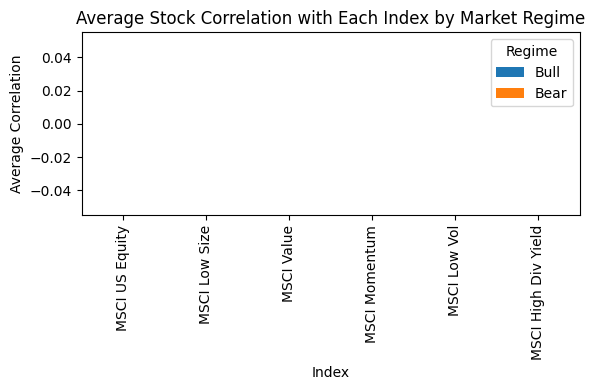

                     Bull  Bear
MSCI US Equity        NaN   NaN
MSCI Low Size         NaN   NaN
MSCI Value            NaN   NaN
MSCI Momentum         NaN   NaN
MSCI Low Vol          NaN   NaN
MSCI High Div Yield   NaN   NaN

In [17]:
# Market regime classification and average correlations
trailing_returns = index_returns['MSCI US Equity'].rolling(window=12).apply(lambda x: (1 + x).prod() - 1)
regime = pd.Series(np.where(trailing_returns > 0, 'Bull', 'Bear'), index=trailing_returns.index)
bull_idx = regime[regime=='Bull'].index
bear_idx = regime[regime=='Bear'].index
avg_corr = {}
for idx in index_cols:
    corr_bull = stock_returns.loc[bull_idx].corrwith(index_returns.loc[bull_idx, idx])
    corr_bear = stock_returns.loc[bear_idx].corrwith(index_returns.loc[bear_idx, idx])
    avg_corr[idx] = {'Bull': corr_bull.mean(), 'Bear': corr_bear.mean()}
avg_corr_df = pd.DataFrame(avg_corr).T
avg_corr_df.plot(kind='bar')
plt.title('Average Stock Correlation with Each Index by Market Regime')
plt.ylabel('Average Correlation')
plt.xlabel('Index')
plt.legend(title='Regime')
plt.show()
avg_corr_df


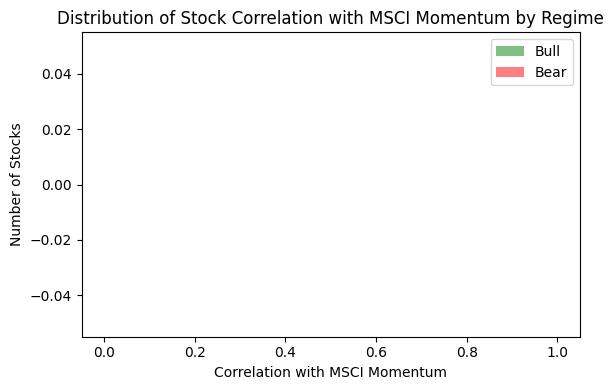

Bull:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN

Bear:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN

In [18]:
# Distribution of stock correlations with MSCI Momentum by regime
corr_bull = stock_returns.loc[bull_idx].corrwith(index_returns.loc[bull_idx, 'MSCI Momentum']).dropna()
corr_bear = stock_returns.loc[bear_idx].corrwith(index_returns.loc[bear_idx, 'MSCI Momentum']).dropna()
plt.figure(figsize=(6,4))
plt.hist(corr_bull, bins=30, color='green', alpha=0.5, label='Bull')
plt.hist(corr_bear, bins=30, color='red', alpha=0.5, label='Bear')
plt.title('Distribution of Stock Correlation with MSCI Momentum by Regime')
plt.xlabel('Correlation with MSCI Momentum')
plt.ylabel('Number of Stocks')
plt.legend()
plt.show()
corr_bull.describe(), corr_bear.describe()
